In [1]:
# Cell 1 — Imports and config
# CM3015 Breast Cancer Detection
# Notebook 02: Hybrid MIL Patch Extraction

import sys
sys.path.append(
    '/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config'
)
import config as cfg

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"\nConfig loaded")
print(f"  PATCH_SIZE:  {cfg.PATCH_SIZE}")
print(f"  STRIDE:      {cfg.STRIDE}")
print(f"  MIN_STD:     {cfg.MIN_STD}")
print(f"  MAX_PATCHES: {cfg.MAX_PATCHES}")
print(f"  RANDOM_SEED: {cfg.RANDOM_SEED}")

NB01   = '/kaggle/input/notebooks/mfjmrizvi/01-dataset-setup-and-eda'
OUTPUT = '/kaggle/working'

Config loaded successfully


2026-05-27 05:26:28.386185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779859588.613871      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779859588.685137      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779859589.226715      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779859589.226753      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779859589.226755      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Config loaded
  PATCH_SIZE:  224
  STRIDE:      224
  MIN_STD:     15
  MAX_PATCHES: 20
  RANDOM_SEED: 42


In [2]:
# Cell 2 — Load linked CSVs from Notebook 01

mass_train = pd.read_csv(f'{NB01}/mass_train_linked.csv')
mass_test  = pd.read_csv(f'{NB01}/mass_test_linked.csv')

print(f"mass_train: {mass_train.shape}")
print(f"mass_test:  {mass_test.shape}")
print(f"\nLabel distribution (train):")
print(mass_train['label'].value_counts())
print(f"\nFull image paths linked:    "
      f"{mass_train['full_image_path'].notna().sum()}")
print(f"Cropped image paths linked: "
      f"{mass_train['cropped_image_path'].notna().sum()}")

mass_train: (1318, 17)
mass_test:  (378, 17)

Label distribution (train):
label
0    681
1    637
Name: count, dtype: int64

Full image paths linked:    1318
Cropped image paths linked: 1318


In [3]:
# Cell 3 — Define patch extraction functions
# These are notebook-specific — not in config
# because they are only used in this notebook

def extract_patches_from_image(image_path, patch_size, stride,
                                min_std, max_patches, seed=42):
    """
    Extract patches from full mammogram via grid scan
    then random sampling for spatial spread.

    Used for:
      - Benign cases (all patches from full mammogram)
      - Context patches for malignant cases

    Returns:
      patches:   (N, patch_size, patch_size, 1) float32 array
      positions: list of (row, col) top-left corners
      kept:      patches after filtering and sampling
      total:     valid patches before sampling
    """
    try:
        img = Image.open(image_path).convert('L')
        img_array = np.array(img, dtype=np.float32) / 255.0
        h, w = img_array.shape

        valid_patches   = []
        valid_positions = []

        for r in range(0, h - patch_size + 1, stride):
            for c in range(0, w - patch_size + 1, stride):
                patch = img_array[r:r+patch_size, c:c+patch_size]
                if patch.std() * 255 < min_std:
                    continue
                valid_patches.append(patch)
                valid_positions.append((r, c))

        total = len(valid_patches)
        if total == 0:
            return None, None, 0, 0

        if total > max_patches:
            rng = np.random.default_rng(seed)
            indices = sorted(
                rng.choice(total, max_patches, replace=False)
            )
            valid_patches   = [valid_patches[i]   for i in indices]
            valid_positions = [valid_positions[i] for i in indices]

        kept = len(valid_patches)
        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, kept, total

    except Exception as e:
        print(f"Error (full): {image_path}: {e}")
        return None, None, 0, 0


def extract_patches_from_roi(cropped_path, patch_size,
                              min_std, seed=42):
    """
    Extract patches from pre-cropped ROI image.

    Used for:
      - Malignant cases only
      - Guarantees lesion tissue is in at least some patches

    If ROI smaller than patch_size, resizes up before extraction.
    Uses 50% overlap stride on ROI for denser coverage.

    Returns:
      patches:   (N, patch_size, patch_size, 1) float32 array
      positions: list of (row, col) top-left corners
      kept:      number of patches extracted
    """
    try:
        img = Image.open(cropped_path).convert('L')
        w, h = img.size

        # Resize up if smaller than patch_size
        if w < patch_size or h < patch_size:
            scale = max(patch_size / w, patch_size / h)
            new_w = max(int(w * scale), patch_size)
            new_h = max(int(h * scale), patch_size)
            img = img.resize((new_w, new_h), Image.LANCZOS)

        img_array = np.array(img, dtype=np.float32) / 255.0
        h, w = img_array.shape

        valid_patches   = []
        valid_positions = []
        roi_stride = patch_size // 2  # 50% overlap for ROI

        for r in range(0, h - patch_size + 1, roi_stride):
            for c in range(0, w - patch_size + 1, roi_stride):
                patch = img_array[r:r+patch_size, c:c+patch_size]
                if patch.std() * 255 < min_std:
                    continue
                valid_patches.append(patch)
                valid_positions.append((r, c))

        # Fallback: centre crop if no valid patches found
        if len(valid_patches) == 0:
            r_s = max(0, (h - patch_size) // 2)
            c_s = max(0, (w - patch_size) // 2)
            patch = img_array[r_s:r_s+patch_size, c_s:c_s+patch_size]
            if patch.shape == (patch_size, patch_size):
                valid_patches.append(patch)
                valid_positions.append((r_s, c_s))

        if len(valid_patches) == 0:
            return None, None, 0

        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, len(valid_patches)

    except Exception as e:
        print(f"Error (ROI): {cropped_path}: {e}")
        return None, None, 0


def extract_hybrid_patches(row, patch_size, stride, min_std,
                            max_patches, seed=42):
    """
    Hybrid MIL extraction strategy:

    MALIGNANT:
      - Primary: patches from cropped ROI
                 (guarantees lesion coverage)
      - Secondary: up to 5 context patches from full mammogram
      - Combined then capped at max_patches total

    BENIGN:
      - All patches from full mammogram
        via random spatial sampling

    This addresses the core MIL challenge: ensuring at least
    some patches contain the lesion for malignant cases.

    Returns:
      patches: (N, patch_size, patch_size, 1) float32 array
      kept:    number of patches
    """
    label = int(row['label'])

    if label == 1:  # MALIGNANT
        roi_patches, _, roi_kept = extract_patches_from_roi(
            row['cropped_image_path'], patch_size, min_std, seed
        )
        full_patches, _, full_kept, _ = extract_patches_from_image(
            row['full_image_path'], patch_size, stride,
            min_std, max_patches=5, seed=seed
        )

        parts = []
        if roi_patches is not None:
            parts.append(roi_patches)
        if full_patches is not None:
            parts.append(full_patches)

        if len(parts) == 0:
            return None, 0

        patches = np.concatenate(parts, axis=0)

        if len(patches) > max_patches:
            rng = np.random.default_rng(seed)
            idx = sorted(
                rng.choice(len(patches), max_patches, replace=False)
            )
            patches = patches[idx]

        return patches, len(patches)

    else:  # BENIGN
        patches, _, kept, _ = extract_patches_from_image(
            row['full_image_path'], patch_size, stride,
            min_std, max_patches, seed
        )
        return patches, kept if patches is not None else 0


print("Patch extraction functions defined:")
print("  extract_patches_from_image  — full mammogram grid sampling")
print("  extract_patches_from_roi    — ROI crop dense sampling")
print("  extract_hybrid_patches      — hybrid MIL strategy")

Patch extraction functions defined:
  extract_patches_from_image  — full mammogram grid sampling
  extract_patches_from_roi    — ROI crop dense sampling
  extract_hybrid_patches      — hybrid MIL strategy


In [4]:
# Cell 4 — Test hybrid extraction on one sample each

print("=== SINGLE IMAGE EXTRACTION TEST ===\n")

for label_val, label_name in [(1, 'MALIGNANT'), (0, 'BENIGN')]:
    sample = mass_train[mass_train['label'] == label_val].iloc[0]
    patches, kept = extract_hybrid_patches(
        sample,
        cfg.PATCH_SIZE, cfg.STRIDE, cfg.MIN_STD, cfg.MAX_PATCHES
    )
    print(f"{label_name}:")
    print(f"  patient_id:     {sample['patient_id']}")
    print(f"  patches kept:   {kept}")
    if patches is not None:
        print(f"  array shape:    {patches.shape}")
        print(f"  pixel range:    "
              f"{patches.min():.3f} — {patches.max():.3f}")
        print(f"  mean pixel val: {patches.mean():.3f}")
    print()

=== SINGLE IMAGE EXTRACTION TEST ===

MALIGNANT:
  patient_id:     P_00001
  patches kept:   11
  array shape:    (11, 224, 224, 1)
  pixel range:    0.000 — 1.000
  mean pixel val: 0.380

BENIGN:
  patient_id:     P_00004
  patches kept:   20
  array shape:    (20, 224, 224, 1)
  pixel range:    0.000 — 1.000
  mean pixel val: 0.227



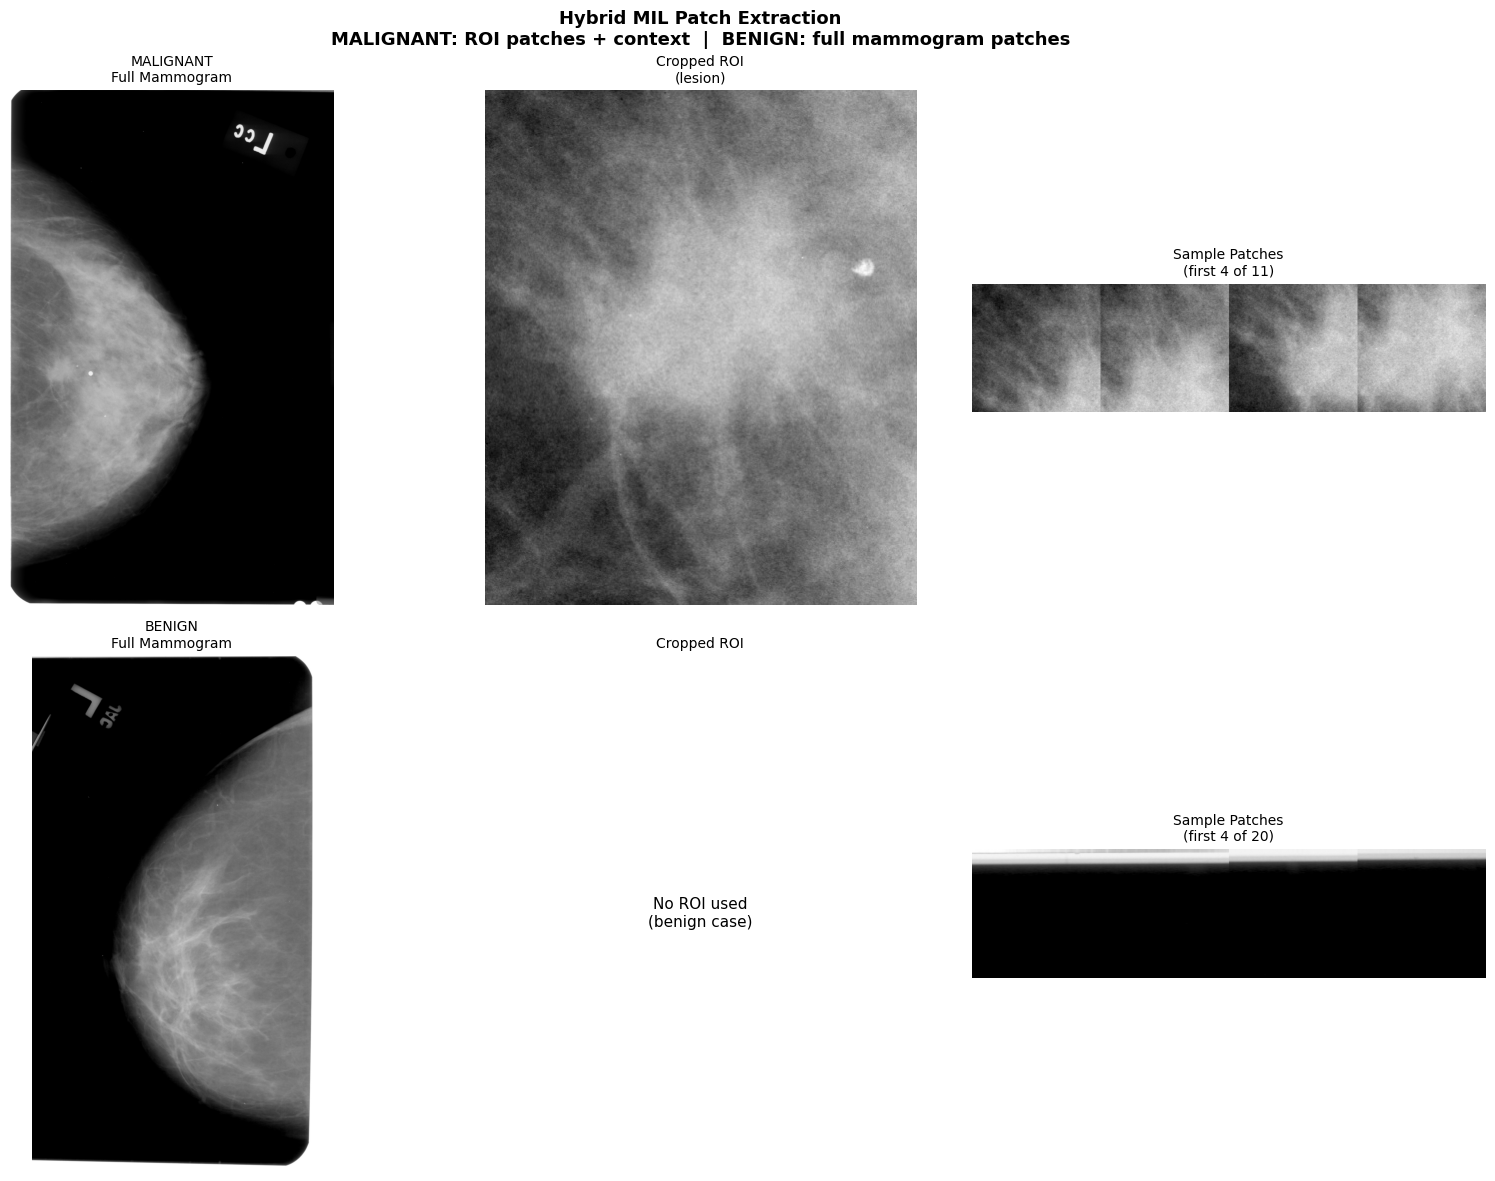

Visualisation saved


In [5]:
# Cell 5 — Visualise hybrid extraction

malignant_row = mass_train[mass_train['label'] == 1].iloc[0]
benign_row    = mass_train[mass_train['label'] == 0].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 12))
fig.suptitle(
    'Hybrid MIL Patch Extraction\n'
    'MALIGNANT: ROI patches + context  |  BENIGN: full mammogram patches',
    fontsize=13, fontweight='bold'
)

for row_idx, (row, label_name) in enumerate(
        [(malignant_row, 'MALIGNANT'), (benign_row, 'BENIGN')]):

    patches, kept = extract_hybrid_patches(
        row, cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES
    )

    # Column 0: full mammogram
    img_full = np.array(
        Image.open(row['full_image_path']).convert('L'))
    axes[row_idx, 0].imshow(img_full, cmap='gray')
    axes[row_idx, 0].set_title(
        f'{label_name}\nFull Mammogram', fontsize=10)
    axes[row_idx, 0].axis('off')

    # Column 1: cropped ROI (malignant) or blank (benign)
    if label_name == 'MALIGNANT':
        img_roi = np.array(
            Image.open(row['cropped_image_path']).convert('L'))
        axes[row_idx, 1].imshow(img_roi, cmap='gray')
        axes[row_idx, 1].set_title('Cropped ROI\n(lesion)', fontsize=10)
    else:
        axes[row_idx, 1].text(
            0.5, 0.5, 'No ROI used\n(benign case)',
            ha='center', va='center', fontsize=11,
            transform=axes[row_idx, 1].transAxes
        )
        axes[row_idx, 1].set_title('Cropped ROI', fontsize=10)
    axes[row_idx, 1].axis('off')

    # Column 2: patch grid
    if patches is not None and kept > 0:
        n_show = min(4, kept)
        grid = np.zeros((cfg.PATCH_SIZE, cfg.PATCH_SIZE * n_show))
        for i in range(n_show):
            grid[:, i*cfg.PATCH_SIZE:(i+1)*cfg.PATCH_SIZE] = \
                patches[i, :, :, 0]
        axes[row_idx, 2].imshow(grid, cmap='gray')
        axes[row_idx, 2].set_title(
            f'Sample Patches\n(first {n_show} of {kept})', fontsize=10)
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/hybrid_extraction_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation saved")

=== PATCH YIELD STATISTICS — 50 IMAGE SAMPLE ===
Failed extractions: 0

Patches per image:
count    50.000000
mean     15.260000
std       6.063642
min       6.000000
25%       9.000000
50%      20.000000
75%      20.000000
max      20.000000
Name: kept, dtype: float64

By label:
       count       mean       std   min   25%   50%   75%   max
label                                                          
0       28.0  20.000000  0.000000  20.0  20.0  20.0  20.0  20.0
1       22.0   9.227273  4.208063   6.0   6.0   7.5  11.0  20.0


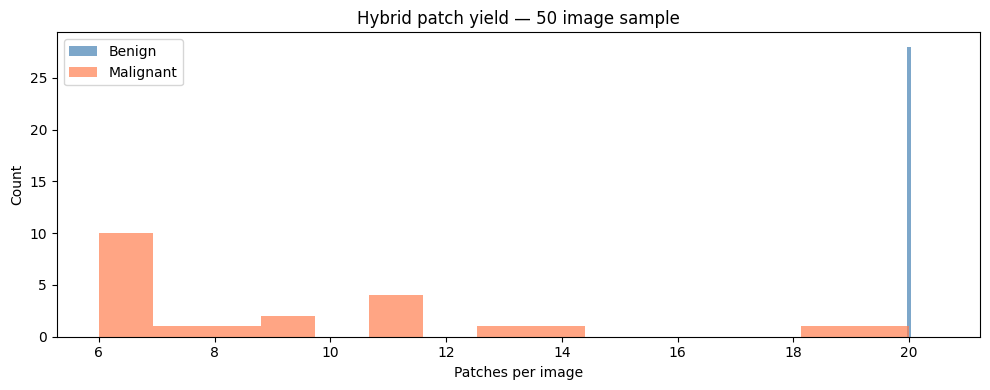

Plot saved


In [6]:
# Cell 6 — Patch yield statistics (50 image sample)

print("=== PATCH YIELD STATISTICS — 50 IMAGE SAMPLE ===")
sample_df = mass_train.head(50)
stats = []

for _, row in sample_df.iterrows():
    patches, kept = extract_hybrid_patches(
        row, cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES
    )
    stats.append({
        'label':  int(row['label']),
        'kept':   kept,
        'failed': patches is None
    })

stats_df = pd.DataFrame(stats)

print(f"Failed extractions: {stats_df['failed'].sum()}")
print(f"\nPatches per image:")
print(stats_df['kept'].describe())
print(f"\nBy label:")
print(stats_df.groupby('label')['kept'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats_df[stats_df['label']==0]['kept'],
        bins=15, alpha=0.7, label='Benign',    color='steelblue')
ax.hist(stats_df[stats_df['label']==1]['kept'],
        bins=15, alpha=0.7, label='Malignant', color='coral')
ax.set_xlabel('Patches per image')
ax.set_ylabel('Count')
ax.set_title('Hybrid patch yield — 50 image sample')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/hybrid_patch_stats.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [7]:
# Cell 7 — Full patch extraction: training set
# This will take several minutes
# Progress printed every 200 images

print("=== FULL HYBRID EXTRACTION — TRAINING SET ===")
print(f"Images to process: {len(mass_train)}")
print(f"Parameters: patch_size={cfg.PATCH_SIZE}, "
      f"stride={cfg.STRIDE}, min_std={cfg.MIN_STD}, "
      f"max_patches={cfg.MAX_PATCHES}\n")

all_patches   = []
all_labels    = []
all_bag_ids   = []
failed_images = []

for idx, row in mass_train.iterrows():
    patches, kept = extract_hybrid_patches(
        row,
        cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES,
        seed=cfg.RANDOM_SEED + idx
    )

    if patches is None or kept == 0:
        failed_images.append(row['patient_id'])
        continue

    all_patches.append(patches)
    all_labels.extend([int(row['label'])] * kept)
    all_bag_ids.extend([idx] * kept)

    if idx % 200 == 0:
        so_far = sum(len(p) for p in all_patches)
        print(f"  {idx}/{len(mass_train)} | "
              f"patches so far: {so_far}")

X_train       = np.concatenate(all_patches, axis=0)
y_train       = np.array(all_labels)
bag_ids_train = np.array(all_bag_ids)

print(f"\n=== TRAINING EXTRACTION COMPLETE ===")
print(f"X_train shape:        {X_train.shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"Failed images:        {len(failed_images)}")
print(f"Memory:               {X_train.nbytes / 1024**3:.2f} GB")

=== FULL HYBRID EXTRACTION — TRAINING SET ===
Images to process: 1318
Parameters: patch_size=224, stride=224, min_std=15, max_patches=20

  0/1318 | patches so far: 11
  200/1318 | patches so far: 2972
  400/1318 | patches so far: 6120
  600/1318 | patches so far: 9147
  800/1318 | patches so far: 11897
  1000/1318 | patches so far: 14991
  1200/1318 | patches so far: 17996

=== TRAINING EXTRACTION COMPLETE ===
X_train shape:        (19770, 224, 224, 1)
y_train distribution: [13616  6154]
Failed images:        0
Memory:               3.70 GB


In [8]:
# Cell 8 — Full patch extraction: test set

print("=== FULL HYBRID EXTRACTION — TEST SET ===")
print(f"Images to process: {len(mass_test)}\n")

test_patches  = []
test_labels   = []
test_bag_ids  = []

for idx, row in mass_test.iterrows():
    patches, kept = extract_hybrid_patches(
        row,
        cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES,
        seed=cfg.RANDOM_SEED + idx
    )

    if patches is None or kept == 0:
        continue

    test_patches.append(patches)
    test_labels.extend([int(row['label'])] * kept)
    test_bag_ids.extend([idx] * kept)

X_test       = np.concatenate(test_patches, axis=0)
y_test       = np.array(test_labels)
bag_ids_test = np.array(test_bag_ids)

print(f"X_test shape:        {X_test.shape}")
print(f"y_test distribution: {np.bincount(y_test)}")
print(f"Memory:              {X_test.nbytes / 1024**2:.1f} MB")

=== FULL HYBRID EXTRACTION — TEST SET ===
Images to process: 378

X_test shape:        (5997, 224, 224, 1)
y_test distribution: [4620 1377]
Memory:              1147.9 MB


In [9]:
# Cell 9 — Save all outputs

print("=== SAVING OUTPUTS ===")

np.save(f'{OUTPUT}/X_train_patches.npy', X_train)
np.save(f'{OUTPUT}/y_train_labels.npy',  y_train)
np.save(f'{OUTPUT}/bag_ids_train.npy',   bag_ids_train)
np.save(f'{OUTPUT}/X_test_patches.npy',  X_test)
np.save(f'{OUTPUT}/y_test_labels.npy',   y_test)
np.save(f'{OUTPUT}/bag_ids_test.npy',    bag_ids_test)

metadata = {
    'patch_size':          cfg.PATCH_SIZE,
    'stride':              cfg.STRIDE,
    'min_std':             cfg.MIN_STD,
    'max_patches':         cfg.MAX_PATCHES,
    'random_seed':         cfg.RANDOM_SEED,
    'strategy':            'hybrid_mil',
    'malignant_source':    'ROI crop patches + up to 5 context patches',
    'benign_source':       'random grid patches from full mammogram',
    'X_train_shape':       list(X_train.shape),
    'X_test_shape':        list(X_test.shape),
    'train_label_counts':  np.bincount(y_train).tolist(),
    'test_label_counts':   np.bincount(y_test).tolist(),
    'failed_train_images': len(failed_images),
}

with open(f'{OUTPUT}/patch_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Files saved:")
for fname in sorted(os.listdir(OUTPUT)):
    size = os.path.getsize(f'{OUTPUT}/{fname}')
    print(f"  {fname}: {size/1024**2:.1f} MB")

print(f"\nMetadata:")
print(json.dumps(metadata, indent=2))

=== SAVING OUTPUTS ===
Files saved:
  .virtual_documents: 0.0 MB
  X_test_patches.npy: 1147.9 MB
  X_train_patches.npy: 3784.1 MB
  bag_ids_test.npy: 0.0 MB
  bag_ids_train.npy: 0.2 MB
  hybrid_extraction_comparison.png: 0.8 MB
  hybrid_patch_stats.png: 0.0 MB
  patch_metadata.json: 0.0 MB
  y_test_labels.npy: 0.0 MB
  y_train_labels.npy: 0.2 MB

Metadata:
{
  "patch_size": 224,
  "stride": 224,
  "min_std": 15,
  "max_patches": 20,
  "random_seed": 42,
  "strategy": "hybrid_mil",
  "malignant_source": "ROI crop patches + up to 5 context patches",
  "benign_source": "random grid patches from full mammogram",
  "X_train_shape": [
    19770,
    224,
    224,
    1
  ],
  "X_test_shape": [
    5997,
    224,
    224,
    1
  ],
  "train_label_counts": [
    13616,
    6154
  ],
  "test_label_counts": [
    4620,
    1377
  ],
  "failed_train_images": 0
}
